### 数値計算  
<details><summary>文献</summary>

* [定量的マクロ経済学と数値計算](https://github.com/quant-macro-book "code")
</details>


### julia 文法

In [1]:
# 実行文の最後に;をつけると、実行結果の表示を省略できる

a = 5;

In [2]:
a = 5

5

In [3]:
# グリッド生成

temp = LinRange(0.1, 1, 10)

10-element LinRange{Float64, Int64}:
 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0

In [4]:
typeof(temp)

LinRange{Float64, Int64}

In [ ]:
# 型をVector{Float64}に変換

grid_w = collect(LinRange(0.1, 1, 10))

10-element Vector{Float64}:
 0.1
 0.2
 0.3
 0.4
 0.5
 0.6
 0.7
 0.8
 0.8999999999999999
 1.0

In [7]:
# 関数を定義する

"""
cons::Real 消費
gamma::Real 相対的リスク回避度
"""

function CRRA(cons::Real, γ::Real);
    if γ != 1
        return cons^(1.0 - γ) / (1.0 - γ)
    else
        return log(cons)
    end
end

CRRA (generic function with 1 method)

In [8]:
cons = 4.0
γ = 2.0

CRRA(cons, γ)

-0.25

In [10]:
cons = 1.0
γ = 1.0

CRRA(cons, γ)

0.0

In [ ]:
# ばらばらに引数を管理するのは面倒なので、structを使う

β = 0.96^30;
γ = 2.0;
cons = 4.0;

In [13]:
# struct 引数の管理に便利

struct Models
    β::Float64
    γ::Float64
    cons::Float64
end

In [18]:
Models(β, γ, cons)

Models(0.29385764323070546, 2.0, 4.0)

In [19]:
# パラメータを設定する

function Calibration()
    β = 0.96^30;
    γ = 2.0;
    cons = 4.0;
    return Models(β, γ, cons)
end

Calibration (generic function with 1 method)

In [20]:
params = Calibration()

Models(0.29385764323070546, 2.0, 4.0)

In [21]:
params.β


0.29385764323070546

### 最適化

In [22]:
struct models2
    β::Float64  # 割引因子
    γ::Float64  # 相対的リスク回避度

    rent::Float64  # 純利子率

    nw::Int64  # 所得グリッドの数
    w_max::Float64  # 所得グリッドの最大値
    w_min::Float64  # 所得グリッドの最小値
    grid_w::Vector{Float64}  # 所得グリッド
end

In [23]:
function Calibration()
    β = 0.985^30
    γ = 2.0
    rent = 1.025^30 - 1.0
    nw = 10
    w_max = 1.0
    w_min = 0.1
    grid_w = collect(LinRange(w_min, w_max, nw))

    return models2(β, γ, rent, nw, w_max, w_min, grid_w)
end

Calibration (generic function with 1 method)

In [25]:
using Pkg
Pkg.activate(".")
Pkg.status()

  Activating project at `c:\Users\ikuto\Documents\Research_code\numerical_computation`


Status `C:\Users\ikuto\Documents\Research_code\numerical_computation\Project.toml`
  [429524aa] Optim v1.13.2
  [91a5bcdd] Plots v1.40.18


In [26]:
using Plots, Optim

[ Info: Precompiling Optim [429524aa-4258-5aef-a3af-852621145aeb] (cache misses: wrong dep version loaded (4), wrong source (2), incompatible header (6))


状態変数 $w$ と制御変数 $a$ をともに離散するのは、モデルを拡張した場合に計算量が指数的に増え、離散化するグリッドを節約すると精度が非常に悪くなる。  
そこで、制御変数については連続とする。  
2期間モデルにおける最適化問題は、$$\max_a{\frac{[w_i - a]^{1-\gamma}}{1-\gamma} + \beta\frac{[(1+r)a]^{1-\gamma}}{1-\gamma}}$$ となる。  
カリブレーションされたパラメータ ${\beta, \gamma, r}$ を所与として、各 $w_i \in {{w_1, ..., w_N}}$ のもとで上式を満たす $a$ を見つける。

In [27]:
"""
a::Float64  貯蓄水準
w_val::Float64  所得水準
params::models2のパラメータ
"""

function obj_two_period(a::Float64, w_val::Float64, params::models2)

    # 1期目の効用
    if w_val - a > 0.0
        util_y = CRRA(w_val - a, params.γ)
    else
        util_y = -Inf  # 貯蓄が所得を超える場合は無効
    end

    # 2期目の効用
    util_o = params.β * CRRA((1.0 + params.rent) * a, params.γ)

    return -(util_y + util_o)  # juliaの最適化は最小化なので、符号を反転

end

obj_two_period (generic function with 1 method)

In [28]:
params = Calibration()

models2(0.6354580927313491, 2.0, 1.0975675790817858, 10, 1.0, 0.1, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8999999999999999, 1.0])

In [29]:
"""
入力
- params::models2のパラメータ

出力
- 最適な貯蓄水準（政策関数）
"""

function optimization(params::models2)

    a_gs = zeros(params.nw)  # 政策関数の初期化, nwはグリッド数

    for i = 1:params.nw  # 各グリッドに対する最適化
        w_val = params.grid_w[i]

        # 関数obj_two_periodを再定義。
        # aのみを引数とする関数をつくる。
        obj_two_period!(a) = obj_two_period(a, w_val, params)  

        # 黄金分割法による計算
        # aの最適値を探す範囲を指定→[w_val*0.01, w_val*2.0]
        res = optimize(obj_two_period!, w_val * 0.01, w_val * 2.0, GoldenSection())

        a_gs[i] = res.minimizer
    end

    return a_gs

end

optimization (generic function with 1 method)

In [30]:
@time a_gs = optimization(params)

10-element Vector{Float64}:
 0.035500888178047925
 0.07100177635609585
 0.10650266453414378
 0.1420035527121917
 0.17750444089023965
 0.21300532906828756
 0.24850621724633548
 0.2840071054243834
 0.3195079857755279
 0.3550088817804793

  0.001068 seconds (22 allocations: 1.547 KiB)


この問題の解析解は、$$a = \frac{w}{1+(1+r)[{\beta(1+r)}]^{-1/\gamma}}$$である。  
解析解とシミュレーション結果が一致するか調べる。

In [31]:
# 解析解

coef1 = (params.β * (1.0 + params.rent))^(-1.0/params.γ)
coef2 = 1.0 / (1.0 + (1.0 + params.rent) * coef1)
a_cfs = coef2 * params.grid_w

10-element Vector{Float64}:
 0.03550088777115455
 0.0710017755423091
 0.10650266331346364
 0.1420035510846182
 0.17750443885577274
 0.21300532662692728
 0.24850621439808182
 0.2840071021692364
 0.3195079899403909
 0.3550088777115455

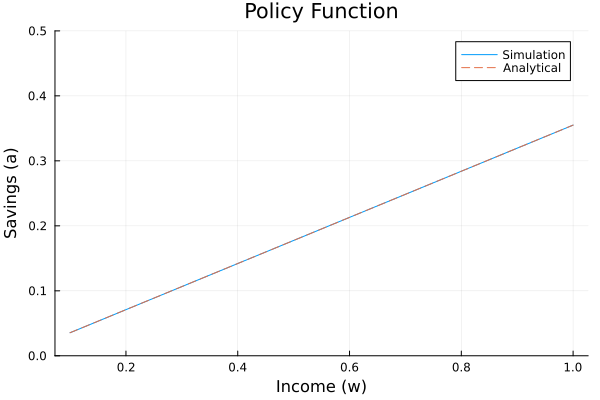

In [33]:
plt = plot(params.grid_w, a_gs, label="Simulation", xlabel="Income (w)", ylabel="Savings (a)", title="Policy Function",
           ylims = (0, 0.5))
plot!(params.grid_w, a_cfs, label="Analytical", linestyle=:dash)

### 求根アルゴリズム

2期間モデルの1階条件（オイラー方程式）は、$$u'(c_1) = \beta(1+r)u'(c_2)$$である。  
これに予算制約式 $c_1 + a = w, c_2 = (1+r)a$ を代入すると、$$u'(w-a) = \beta(1+r)u'((1+r)a)$$となる。  
この式に関して、前節と同様に状態変数 $w_i$ については離散化し、所与である。そうすると、未知の変数は制御変数である $a$ のみとなる。  
そこで、上式について残差を取ってみる。$$R(w_i;a) := \beta(1+r)\frac{u'((1+r)a)}{u'(w_i-a)}-1$$ ※ $w_i$ に付いている添え字$i$は何番目のグリッドかを表している。  
この変換によってわかることは、$R(w_i;a) = 0$ となる点を見つけること（求根問題）が1階条件を解くことと同義であるということ。  


In [34]:
# 限界効用を定義

function mu_CRRA(cons::Float64, γ::Float64)
    return cons ^ (-γ)
end

mu_CRRA (generic function with 1 method)

In [35]:
using Roots

[ Info: Precompiling RootsForwardDiffExt [a63bd285-541a-50a0-818b-605bb84ce7b2] (cache misses: wrong dep version loaded (4), incompatible header (4))


In [36]:
# 残差関数の定義

function resid_two_period(a::Float64, w_val::Float64, params::models2)

    if w_val - a > 0.0
        mu1 = mu_CRRA(w_val - a, params.γ)
    else
        mu1 = -Inf  # 貯蓄が所得を超える場合は無効
    end

    mu2 = mu_CRRA((1.0 + params.rent) * a, params.γ)

    return params.β * (1.0 + params.rent) * (mu2 / mu1) - 1.0

end

resid_two_period (generic function with 1 method)

In [39]:
# ゼロ点を探す関数の定義

function Root_find(params::models2)

    a_nl = zeros(params.nw)

    for i = 1:params.nw

        w_val = params.grid_w[i]

        # 1変数の関数にする
        resid_two_period!(a) = resid_two_period(a, w_val, params)

        a_nl[i] = find_zero(resid_two_period!, 0.01)

    end

    return a_nl

end

Root_find (generic function with 1 method)

In [40]:
@time a_nl = Root_find(params)

10-element Vector{Float64}:
 0.03550088777115455
 0.0710017755423091
 0.10650266331346363
 0.1420035510846182
 0.17750443885577274
 0.21300532662692728
 0.2485062143980818
 0.2840071021692364
 0.3195079899403909
 0.3550088777115455

  0.002439 seconds (2 allocations: 144 bytes)


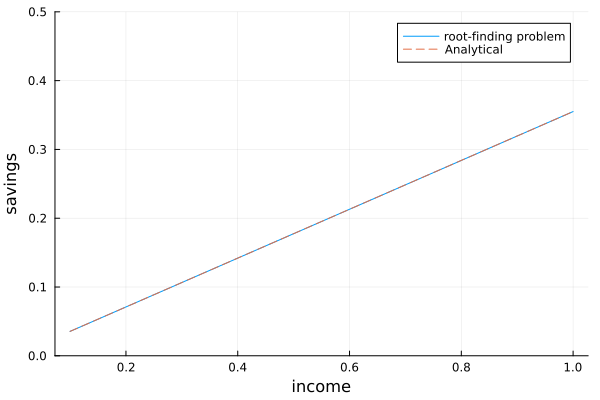

In [41]:
plt = plot(params.grid_w, a_nl, label="root-finding problem", xlabel="income", ylabel="savings", legend=:topright,
            ylims = (0, 0.5))

# 解析解
plot!(params.grid_w, a_cfs, label="Analytical", linestyle=:dash)

### 射影法

最適化と求根アルゴリズムを用いた手法は、所得水準 $w$ を離散化してグリット点上で最適貯蓄を計算している点で共通していた。  
一方、射影法では政策関数全体をパラメトリックに近似するアプローチをとる。  
例えば、貯蓄関数 $a = g(w)$ を $M$次の多項式$$a = g(w) \approx \hat{g}(w;\mathbf{\theta}) = \sum^M_{m=0}\theta_mw^m$$で近似したいとする。このとき、射影法とは、オイラー方程式を満たす政策関数を見つけるという問題を、多項式における未知の係数ベクトル $\mathbf{\theta} := {\theta_m}^M_{m=0}$ を探す問題に置き換えるアプローチである。  
より一般的には、近似された政策関数は$$\hat{g}(w;\mathbf{\theta}) = \sum^M_{m=0}\theta_m\Phi_m(w)$$と書くことができる。このとき、$\Phi_m(w)$ は*基底関数*と呼ばれる。基底関数の選択によって射影法のアルゴリズムも変わってくる。よくシェビチェフ多項式が用いられる。

多項式がうまく政策関数（貯蓄関数）を近似できていれば、残差関数 $R(w_i;a) = \beta(1+r)\frac{u'((1+r)a)}{u'(w_i-a)}-1$ に $a \approx \hat{g}(w;\mathbf{\theta})$ を代入した場合の残差はゼロに近いはずである。すなわち、$$R(w_i;\mathbf{\theta}) = \beta(1+r)\frac{u'((1+r)\hat{g}(w;\mathbf{\theta}))}{u'(w_i-\hat{g}(w;\mathbf{\theta}))}-1 = 0$$が「あらゆる $w$ で」成立している。  
とはいっても誤差は生じるので当てはまりの良さを距離関数 $\rho$ で定義する。  
一般的に政策関数を探す問題は、$$\mathbf{\theta}^* = \arg\min_{\mathbf{\theta}}{\rho(R(w;\mathbf{\theta}),\mathbf{0})}$$を満たす $\mathbf{\theta}^*$ を探す問題に置き換えることができる。  
距離関数の選び方は様々あるがここでは*選点法*を用いる（他にはガラーキン法などがある）。選点法とは、残差を有限個の代表点 $\{w_i\}^N_{i=1}$ でゼロにするように近似政策関数のパラメータを決める方法である。

> 選点法  
1. 基底関数（例：チェビシェフ多項式）を選ぶ
2. 政策関数や価値関数をその基底の線形結合で表す
3. ガラ―キン法や選点法で残差がゼロになるように係数を決定する
4. 近似関数を得る

In [42]:
using LeastSquaresOptim

[ Info: Precompiling LeastSquaresOptim [0fc2ff8b-aaa3-5acd-a817-1944a5e08891] (cache misses: incompatible header (2))


In [43]:
# 準備

# 多項式の係数を1つ定める
θ = [0.0, 1.0]

# 選点法の評価点
colloc = params.grid_w

10-element Vector{Float64}:
 0.1
 0.2
 0.3
 0.4
 0.5
 0.6
 0.7
 0.8
 0.8999999999999999
 1.0

In [44]:
# 政策関数を多項式で近似する

"""
入力
coef 多項式の係数
eval 選点

出力
next_a 2期における選点上の資産水準（a）
"""

function approx_policy(coef::Vector{Float64}, eval::Vector{Float64})

    # 多項式の最大次数
    dim_app = length(coef) - 1

    nw = length(colloc)

    # 選点上の多項式：w^i
    poly = zeros(nw, dim_app + 1)
    for i = 0:dim_app
        poly[:, i+1] = colloc .^i
    end

    next_a = poly * coef

    return next_a

end

approx_policy (generic function with 1 method)

In [45]:
# 選点に基づいてオイラー方程式の残差を返す

"""
入力
coef 多項式の係数
params パラメータ

出力
residual 残差
"""

function resid_projection(coef::Vector{Float64}, params::models2)

    a = approx_policy(coef, params.grid_w)

    # 近似したaを使って、1期の消費水準を計算
    c1 = params.grid_w - a

    # 2期の消費水準を計算
    c2 = (1.0 + params.rent) * a

    mu1 = zeros(params.nw)
    mu2 = similar(mu1)
    resid = similar(mu1)

    for i = 1:params.nw
        if c1[i] > 0.0
            mu1[i] = mu_CRRA(c1[i], params.γ)
        else
            mu1[i] = 10000.0
        end

        if c2[i] > 0.0
            mu2[i] = mu_CRRA(c2[i], params.γ)
        else
            mu2[i] = 10000.0
        end

        resid[i] = params.β * (1.0 + params.rent) * (mu2[i] / mu1[i]) - 1.0

    end

    return resid

end

resid_projection (generic function with 1 method)

In [ ]:
# 射影法によって2期間モデルを解く

"""
入力
params パラメータ
coef_init 初期係数

出力
res.minimizer 非線形最小二乗法によって得られた係数
res.converged 最適化が収束したかどうか
next_a 近似された政策関数
"""

function projection(params::models2, θ_init = [0.1, 0.35])

    resid_projection!(coef) = resid_projection(coef, params)

    res = LeastSquaresOptim.optimize(resid_projection!, θ_init, LevenbergMarquardt()) # レーベンバーグ・マルクワルト法を使用

    next_a = approx_policy(res.minimizer, params.grid_w)

    return res.minimizer, res.converged, next_a

end

projection (generic function with 2 methods)

In [47]:
@time res = projection(params)

  1.053835 seconds (1.43 M allocations: 73.164 MiB, 3.27% gc time, 97.92% compilation time)


([1.013305701289326e-12, 0.3550088777075531], true, [0.03550088777176862, 0.07100177554252393, 0.10650266331327923, 0.14200355108403456, 0.17750443885478986, 0.21300532662554517, 0.24850621439630047, 0.2840071021670558, 0.3195079899378111, 0.35500887770856643])

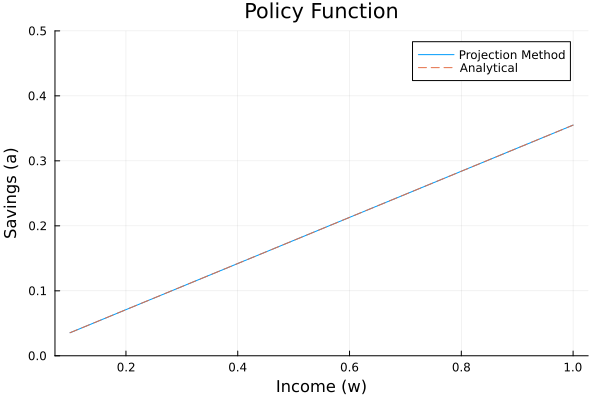

In [48]:
plt = plot(params.grid_w, res[3], label="Projection Method", xlabel="Income (w)", ylabel="Savings (a)", title="Policy Function",
           ylims = (0, 0.5))
plot!(params.grid_w, a_cfs, label="Analytical", linestyle=:dash)

### 内生的グリッド法（EGM）

オイラー方程式に基づきながらグリッドのとり方を工夫する。  
状態変数である $w$ ではなく、**制御変数である $a$ を離散化**し、その所得が実現するような $a$ を逆算して求める。